Original equation: y = -4.21x + 0.70
Custom LS -> Slope: -4.16, Intercept: 0.62
NumPy LS -> Slope: -4.16, Intercept: 0.62
Max residual: 1.052 at X = 0.04
Min residual: -0.931 at X = 0.87


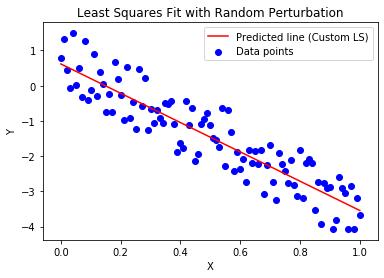

In [6]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Choose a random linear function
m_orig = random.uniform(-5, 5)
c_orig = random.uniform(-5, 5)
print(f"Original equation: y = {m_orig:.2f}x + {c_orig:.2f}")

# Step 2: Data points
X = np.arange(0, 1.01, 0.01)  # 0 to 1 in steps of 0.01
Y = []
for i in range(len(X)):
    # y = mx + c + random perturbation between -1 and 1
    perturb = np.random.uniform(0, 1) * (-1 if random.random() < 0.5 else 1)
    Y.append(m_orig * X[i] + c_orig + perturb)
Y = np.array(Y)

# Step 3: Design matrix
A = np.vstack([X, np.ones(len(X))]).T

# Step 4: Custom least squares
def my_least_squares(A, b):
    AtA = np.dot(A.T, A)
    Atb = np.dot(A.T, b)
    x = np.linalg.solve(AtA, Atb)
    return x

# Step 5: Solve using custom LS
coeff_custom = my_least_squares(A, Y)
m_custom, c_custom = coeff_custom
print(f"Custom LS -> Slope: {m_custom:.2f}, Intercept: {c_custom:.2f}")

# Step 6: Solve using NumPy LS
coeff_numpy = np.linalg.lstsq(A, Y, rcond=None)[0]
m_np, c_np = coeff_numpy
print(f"NumPy LS -> Slope: {m_np:.2f}, Intercept: {c_np:.2f}")

# Step 7: Predicted values and residuals
Y_fit = m_custom * X + c_custom
residuals = Y - Y_fit

# Identify largest and smallest residuals
max_idx = np.argmax(residuals)
min_idx = np.argmin(residuals)
print(f"Max residual: {residuals[max_idx]:.3f} at X = {X[max_idx]:.2f}")
print(f"Min residual: {residuals[min_idx]:.3f} at X = {X[min_idx]:.2f}")

# Step 8
plt.scatter(X, Y, label='Data points', color='blue')
plt.plot(X, Y_fit, color='red', label='Predicted line (Custom LS)')
plt.title("Least Squares Fit with Random Perturbation")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()